In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ahmedesso/brest-cancer/data.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/ahmedesso/brest-cancer/data.csv")
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [3]:
from sklearn.model_selection import train_test_split

In [4]:
df["diagnosis"] = df["diagnosis"].map({"M":1, "B":-1})

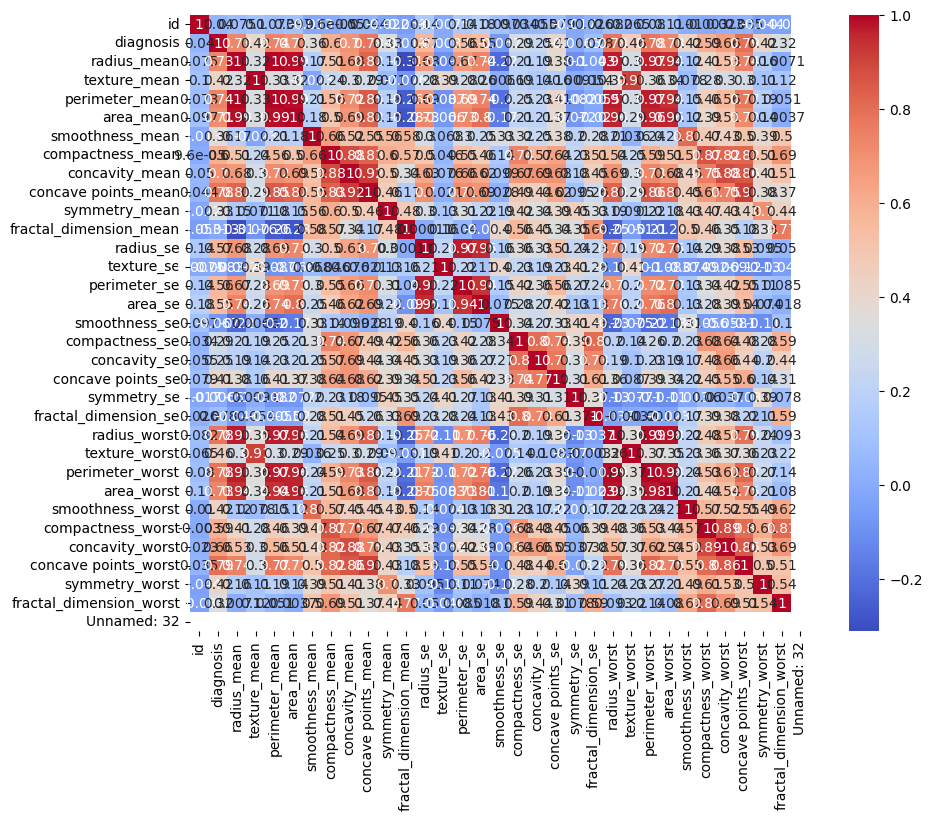

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [6]:
x = df[["radius_mean", "concave points_mean"]]
y = df["diagnosis"]

In [7]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,random_state=42, test_size=0.2)

In [8]:
len(x.columns)

2

In [9]:
np.random.seed(42)
w = np.random.rand(len(x.columns))*10
b = np.random.rand()*10
w,b

(array([3.74540119, 9.50714306]), 7.319939418114051)

In [10]:
z = lambda x: w.T@x+b

In [11]:
z(np.array(xtrain.iloc[1]))

np.float64(87.73271908541203)

In [12]:
yhat = lambda x : (1 if z(x)>0 else -1)

In [13]:
yhat(np.array(xtrain.iloc[1]))*ytrain.iloc[1]

np.int64(1)

In [14]:
hloss = lambda d : max(0,1-y.loc[d.name]*z(np.array(d)))

In [15]:
sum(xtrain.apply(lambda x : hloss(x), axis=1))/len(xtrain)

34.02897043897833

In [16]:
df.describe()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,-0.254833,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,0.967836,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,-1.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,-1.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,-1.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [17]:
dw = lambda x,y : np.array(-y*x)
db = lambda x,y : 1

In [18]:
dw(xtrain.iloc[0], ytrain.iloc[0]), db(xtrain.iloc[0], ytrain.iloc[0])

(array([9.029  , 0.04375]), 1)

In [19]:
def train(x,y,a):
    global w,b
    weight=dw(x,y)
    bias = db(x,y)
    if yhat(x)*z(x)<1:
        print(yhat(x)*z(x))
        w -= a*weight
        b -= a*bias
    # w-= a*weight
    # b-=a*bias
    

In [20]:
# train(xtrain,ytrain,1)
# sum(xtrain.apply(lambda x : hloss(x), axis=1))/len(xtrain)

In [21]:
print(sum(xtrain.apply(lambda x : hloss(x), axis=1))/len(xtrain))
for i in range(10):
    xtrain.apply(lambda x : train(x,ytrain.loc[x.name],0.1), axis=1)
    print(i,sum(xtrain.apply(lambda x : hloss(x), axis=1))/len(xtrain))

34.02897043897833
0 34.02897043897833
1 34.02897043897833
2 34.02897043897833
3 34.02897043897833
4 34.02897043897833
5 34.02897043897833
6 34.02897043897833
7 34.02897043897833
8 34.02897043897833
9 34.02897043897833


In [22]:
w,b

(array([3.74540119, 9.50714306]), 7.319939418114051)

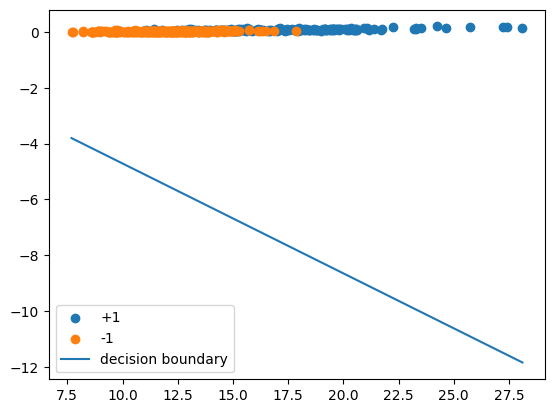

In [23]:
plt.scatter(xtrain[ytrain==1].iloc[:,0],xtrain[ytrain==1].iloc[:,1], label="+1")
plt.scatter(xtrain[ytrain==-1].iloc[:,0],xtrain[ytrain==-1].iloc[:,1], label="-1")
x1 = np.linspace(xtrain.iloc[:,0].min(), xtrain.iloc[:,0].max(),100)
x2 = -(w[0]*x1+b)/w[1]
plt.plot(x1,x2, label="decision boundary")
plt.legend()
plt.show()